# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 4, часть 2. Нейронные сети.


**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_ds25_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.

**Правила оформления теоретических задач:**

* Решения необходимо оформить в виде $\LaTeX$ в markdown-ячейках. Иные способы (в т.ч. фотографии) не принимаются.
* Если вы не знаете $\LaTeX$, используйте ИИ-инструменты для оформления черновика решения. Примеры были показаны на лекции 2 по ИИ-инструментам.
* **В решениях поясняйте, чем вы пользуетесь**, хотя бы кратко. 
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.


<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `...`.
* В markdown-ячейка, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.


**Баллы за задание:**

<b><font color="blue">Легкая часть</font></b> (достаточно на "хор"):

* Задача 2 &mdash; 40 баллов.

<b><font color="orange">Сложная часть</font></b> (необходимо на "отл"):

* Задача 3 &mdash; 80 баллов;
* Задача 4 &mdash; 50 баллов.

Баллы учитываются в <b>обязательной части</b> курса и не влияют на оценку по факультативной части.

In [111]:
# Bot check

# HW_ID: fpmi_ad4_part2
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [65]:
from typing import Tuple
import numpy as np
from sklearn import datasets

from IPython.display import clear_output
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

import torch
import numpy as np
from torchvision import datasets, transforms
from torchvision.datasets import MNIST
from typing import Tuple

from scipy.special import logsumexp
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

sns.set(palette="Set2")
cm_bright = ListedColormap(["#FF3300", "#00CC66"])

В условии задания обозначены области, в которых запрещено использование ИИ-инструментов. Это не исчерпывающий список. Подробные правила можно найти <a href="https://thetahat.ru/courses/ai-rules">по ссылке на сайте</a>. В частности, запрещено применять ИИ-инструменты при решении теоретических частей задач, ответах на вопросы и написании выводов.

---
### <font color="blue"><i>Легкая часть</i></font>

---
### Задача 2.

**При решении задачи запрещено пользоваться ИИ-инструментами,** но можно при оформлении решения.

Рассмотрим двухслойную полносвязную нейронную сеть, которая принимает на вход $x\in\mathbb{R}^d$ и возвращает $y\in\{0, 1\}$
$$y_\theta(x) = \sigma_2 \big( \sigma_1 \left( x^{\top} W_1 + b_1 \right) W_2 + b_2 \big),$$
где 
* $W_1 \in \mathbb{R}^{d \times h}, b_1 \in \mathbb{R}^{h}$ &mdash; параметры 1-го слоя,
* $W_2 \in \mathbb{R}^{h \times 1}, b_2 \in \mathbb{R}$ &mdash; параметры 2-го слоя,
* $\theta = (W_1, b_1, W_2, b_2)$ — все параметры нейросети,
* $\sigma_1(x) = \tanh x = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}$ &mdash; гиперболический тангенс, функция активации 1-го слоя, применяется поэлементно,
* $\sigma_2(x) = \frac{1}{1 + e^{-x}}$ &mdash; логистическая сигмоида, функция активации 2-го слоя.

**1.** Нарисуйте схематически данную нейронную сеть. Сколько у нее обучаемых параметров?

*Для вставки изображения скопируйте его и вставьте в ячейку markdown с помощью `Ctrl+V`. Должно появится либо большое количество символов (Colab), либо что-то вроде `![image.png](attachment:image.png)`.*

Всего обучаемых параметров d*h + h + h + 1 = h(2 + d) + 1 - первая матрица весов, b_1, вторая матрица весов, b_2
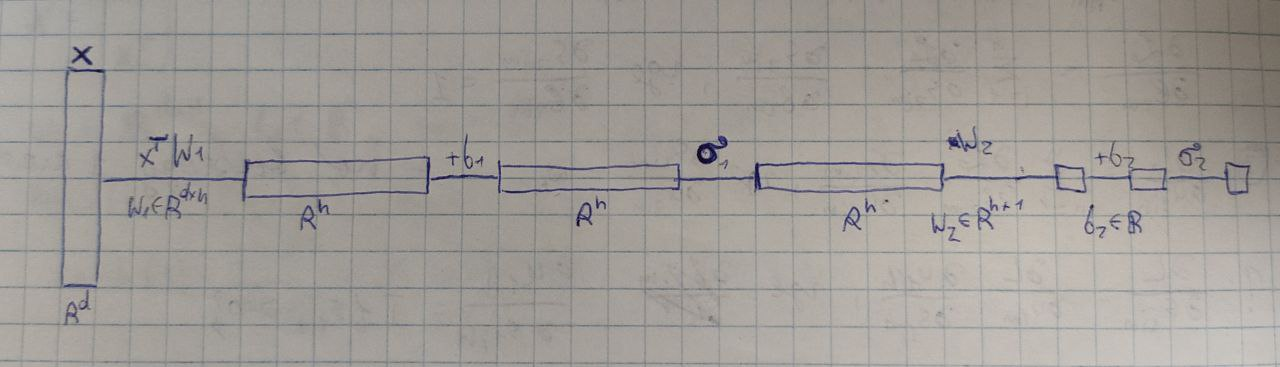

**2.** Дана обучающая выборка $X \in \mathbb{R}^{n \times d}$ — матрица входных данных и $Y \in \{0, 1\}^{n}$ — таргет. Нейронная сеть обучается по этой выборке, минимизируя заданную функцию $\mathscr{L}$, в данном случае рассмотрим кросс энтропию
$$\mathscr{L}(\theta) = -\sum_{i=1}^n \big( Y_i \log y_\theta(X_i) + (1-Y_i) \log \left(1-y_\theta(X_i)\right) \big).$$

Наша цель — определить оптимальные параметры нашей модели, минимизируя функцию $\mathscr{L}(\theta)$ на заданном наборе данных. Мы будем решать эту задачу с помощью метода градиентного спуска, который требует вычисления производных по всем параметрам сети. Конечно, в данном случае несложно выписать все производные напрямую, с чем каждый из вас легко сможет справиться.

Однако прямое вычисление производных имеет квадратичную зависимость от количества параметров, что делает его неэффективным. Из-за этого мы не смогли бы быстро обучать глубокие нейронные сети. Хотя в данном случае речь идёт всего лишь о двух слоях, понимание работы методов на простых примерах было бы полезно.

На лекции был рассказан метод **обратного распространения ошибки (back propagation)** и показан его пример для двухслойной нейронной сети (на доске). Выпишите все необходимые производные для применения метода back propagation.

- **Входные данные**:
  $$X \in \mathbb{R}^{n \times d} \quad \text{(батч из $n$ векторов по $d$ признаков)}$$

- **Первый (скрытый) слой**:
  $$
  \mathbf{s}_1 = X\mathbf{W}_1 + \mathbf{b}_1, \quad 
  \begin{cases}
  \mathbf{W}_1 \in \mathbb{R}^{d \times h} \\
  \mathbf{b}_1 \in \mathbb{R}^{n \times h}
  \end{cases}
  $$
  $$
  \mathbf{u}_1 = \tanh(\mathbf{s}_1)
  $$

- **Второй (выходной) слой**:
  $$
  \mathbf{s}_2 = \mathbf{u}_1\mathbf{W}_2 + \mathbf{b}_2, \quad 
  \begin{cases}
  \mathbf{W}_2 \in \mathbb{R}^{h \times 1} \\
  \mathbf{b}_2 \in \mathbb{R}^{n \times 1}
  \end{cases}
  $$
  $$
  \mathbf{u}_2 = \sigma(\mathbf{s}_2) = \frac{1}{1+e^{-\mathbf{s}_2}}
  $$

- **Функция потерь (кросс-энтропия)**:
  $$
  \mathcal{L} = -\sum_{i=1}^n \left[Y_i\log(u_{2,i}) + (1-Y_i)\log(1-u_{2,i})\right]
  $$

## Формулы обратного распространения ошибки
### Обратный проход:

1. Градиент по выходному слою:
$$
\frac{\partial \mathcal{L}}{\partial U_{2im}} = \frac{Y_i}{U_{2im}} - \frac{1 - Y_i}{1 - U_{2im}}
$$

2. Градиент перед сигмоидой:
$$
\frac{\partial \mathcal{L}}{\partial S_{2im}} = \frac{1}{e^{-S_{2im}} + 1} - Y_i
$$

3. Градиенты весов второго слоя:
$$
\frac{\partial \mathcal{L}}{\partial W_{2hm}} = \sum_{i=1}^n \frac{\partial \mathcal{L}}{\partial S_{2im}} \cdot U_{1ih}
$$

4. Градиент смещения второго слоя:
$$
\frac{\partial \mathcal{L}}{\partial b_{2m}} = \sum_{i=1}^n \frac{\partial \mathcal{L}}{\partial S_{2im}} \cdot 1
$$

5. Градиент по скрытому слою:
$$
\frac{\partial \mathcal{L}}{\partial U_{1ih}} = \sum_{m=1}^M \frac{\partial \mathcal{L}}{\partial S_{2im}} \cdot w_{hm}
$$

6. Градиент перед tanh:
$$
\frac{\partial \mathcal{L}}{\partial S_{1ih}} = \frac{\partial \mathcal{L}}{\partial U_{1ih}} \cdot \frac{1}{\cosh^2 (S_{1ih})}
$$

7. Градиенты весов первого слоя:
$$
\frac{\partial \mathcal{L}}{\partial W_{1jh}} = \sum_{i=1}^n \frac{\partial \mathcal{L}}{\partial S_{1ih}} \cdot x_{ij}
$$

8. Градиент смещения первого слоя:
$$
\frac{\partial \mathcal{L}}{\partial b_{1h}} = \sum_{i=1}^n \frac{\partial \mathcal{L}}{\partial S_{1ih}} \cdot 1
$$

### Примечания:
- $\cosh^{-2}$ - производная чосинуса
- Индексы: $i$ - примеры, $h$ - количество нейронов первого слоя

**3.** Выпишите итоговый алгоритм обратного распространения ошибки для данной нейросети. Нужно записать все необходимые вычисления, включая все итоговые формулы производных. Подробно поясните, почему он имеет линейную сложность.

## Полные формулы обратного распространения ошибки (одномерный выход, m=1)

### Прямой проход:
$$
y(\theta) = U_2 = \sigma(S_2) = \sigma(U_1W_2 + b_2^T)
$$

### Обратный проход:

1. Градиент по выходу активации:
$$
\frac{\partial \mathcal{L}}{\partial U_{2i}} = \frac{Y_i}{U_{2i}} - \frac{1 - Y_i}{1 - U_{2i}}
$$

2. Градиент перед сигмоидой:
$$
\frac{\partial \mathcal{L}}{\partial S_{2i}} = \frac{1}{e^{-S_{2i}} + 1} - Y_i
$$

3. Градиенты весов второго слоя:
$$
\frac{\partial \mathcal{L}}{\partial W_{2h}} = \sum_{i=1}^n \left( \frac{1}{e^{-S_{2i}} + 1} - Y_i \right) \cdot U_{1ih}
$$

4. Градиент смещения второго слоя:
$$
\frac{\partial \mathcal{L}}{\partial b_{2}} = \sum_{i=1}^n \left( \frac{1}{e^{-S_{2i}} + 1} - Y_i \right)
$$

5. Градиент по скрытому слою:
$$
\frac{\partial \mathcal{L}}{\partial U_{1ih}} = \left( \frac{1}{e^{-S_{2i}} + 1} - Y_i \right) \cdot W_{2h}
$$

6. Градиент перед tanh:
$$
\frac{\partial \mathcal{L}}{\partial S_{1ih}} = \left( \frac{1}{e^{-S_{2i}} + 1} - Y_i \right) \cdot W_{2h} \cdot \frac{1}{\cosh^2 (S_{1ih})}
$$

7. Градиенты весов первого слоя:
$$
\frac{\partial \mathcal{L}}{\partial W_{1jh}} = \sum_{i=1}^n \left( \frac{1}{e^{-S_{2i}} + 1} - Y_i \right) \cdot W_{2h} \cdot \frac{1}{\cosh^2 (S_{1ih})} \cdot X_{ij}
$$

8. Градиент смещения первого слоя:
$$
\frac{\partial \mathcal{L}}{\partial b_{1h}} = \sum_{i=1}^n \left( \frac{1}{e^{-S_{2i}} + 1} - Y_i \right) \cdot W_{2h} \cdot \frac{1}{\cosh^2 (S_{1ih})}
$$

- j - номер входного признака

**Выводы:**

Переиспользование промежуточных результатов позволяет выычислять градиентный спуск за линейное время, в отличие от метода "в лоб", который даёт квадратичную сложность.

**Внимание!** Решение, которое будет иметь сверхлинейную сложность, не будет оценено совсем. Считать производные вы все умеете, задача — вычислять их эффективно алгоритмически.

---
### <font color="orange"><i>Сложная часть</i></font>

---
### Задача 3.

**1.** На практике, чтобы сделать численные вычисления градиентов более стабильными, в качестве функции ошибки используют композицию бинарной кроссэнтропии и сигмоиды, передавая ей логиты в качестве аргументов, то есть выходы последнего линейного слоя. Выведите итоговую формулу градиента бинарной кроссэнтропии по выходу сети до применения сигмоиды.

$$
\mathcal{L} = -\sum_{i=1}^n \left[Y_i\log(\sigma(s_i)) + (1-Y_i)\log(1-\sigma(s_i))\right]
$$
- Производная сигмоиды:
   $$
   \frac{d\sigma(s_i)}{ds_i} = \sigma(s_i)(1-\sigma(s_i))
   $$

- Градиент по логитам:
   $$
   \frac{\partial\mathcal{L}}{\partial s_i} = -\left[\frac{Y_i}{\sigma(s_i)} - \frac{1-Y_i}{1-\sigma(s_i)}\right] \cdot \sigma(s_i)(1-\sigma(s_i))
   $$

- Упрощение:
   $$
   \frac{\partial\mathcal{L}}{\partial s_i} = \sigma(s_i) - Y_i
   $$

### Итоговая формула для батча

Для матрицы логитов $\mathbf{s} \in \mathbb{R}^{n \times 1}$:
$$
\frac{\partial\mathcal{L}}{\partial\mathbf{s}} = \sigma(\mathbf{s}) - \mathbf{Y} \quad \text{(размерность: $n \times 1$)}
$$

**2.** Реализуйте класс обучения нейронной сети из задачи 2 в sklearn-стиле, используя только библиотеку `numpy`. Используйте представленный ниже шаблон.

**Особенности:**
* Функция `_backward` должна реализовывать метод back propagation полностью на основе формул из задачи 2. Функция должна *накапливать* градиенты, подробнее см. <a href="https://thetahat.ru/courses/ad/main/4/nn_simple_examples">ноутбук с занятия по нейросетям</a>.
* При реализации функции `_backward` необходимо сразу посчитать производную функции ошибку по выходу сети до применения функции активации, что в коде реализуется функцией `output_gradient`. Это необходимо для повышения стабильности численных вычислений, что также используется в PyTorch. 
* Желательно, чтобы градиент не зависел от размера входных данных, поэтому при вычислении градиентов по параметрам, рекомендуется разделить их на размер батча.
* При необходимости вы можете менять внутреннюю структуру методов, кроме методов `__init__`, `fit`, `predict`, `predict_proba`. В случае изменений исправляйте также документацию и типизацию аргументов, иначе оценка может быть снижена.
* **При реализации класса запрещено пользоваться ИИ-инструментами.** За исключением случаев обновления документации класса при необходимости.

In [43]:
# При реализации класса запрещено пользоваться ИИ-инструментами.


class TwoLayersNNClassifier:
    """Двухслойная нейронная сеть для задачи бинарной классификации.

    Параметры:
        input_size (int): Размер входного вектора.
        hidden_size (int): Количество нейронов в скрытом слое.
        learning_rate (float, optional): Скорость обучения (по умолчанию 0.01).
        n_epoch (int, optional): Количество эпох обучения (по умолчанию 100).
        weight_init_scale (float, optional): Масштаб для инициализации весов (по умолчанию 1).
    """

    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        learning_rate: float = 0.01,
        n_epoch: int = 100,
        weight_init_scale: float = 1,
    ):
        self.learning_rate = learning_rate
        self.n_epoch = n_epoch
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.weight_init_scale = weight_init_scale

        # Инициализация весов
        self._initialize_weights()

        # Инициализация градиентов
        self._zero_grad()

        # Для хранения истории потерь
        self.loss_history = []

    def _initialize_weights(self):
        """Инициализирует веса сети случайными значениями."""
        self.W1 = self._init_weight_matrix(self.input_size, self.hidden_size)
        self.b1 = self._init_weight_matrix(1, self.hidden_size)
        self.W2 = self._init_weight_matrix(self.hidden_size, 1)
        self.b2 = self._init_weight_matrix(1, 1)

    def _init_weight_matrix(self, rows: int, cols: int) -> np.ndarray:
        """Инициализирует матрицу весов случайными значениями.

        Параметры:
            rows (int): Количество строк.
            cols (int): Количество столбцов.

        Возвращает:
            np.ndarray: Матрица весов.
        """
        return (np.random.rand(rows, cols) * 2 - 1) * self.weight_init_scale

    @staticmethod
    def tanh_derivative(x: np.ndarray) -> np.ndarray:
        """Вычисляет производную функции гиперболического тангенса.

        Параметры:
            x (np.ndarray): Входной массив.

        Возвращает:
            np.ndarray: Производная функции tanh.
        """
        return 1 - np.tanh(x)**2  # Для численной устойчивости

    @staticmethod
    def sigmoid(x: np.ndarray, scale: int = 1000) -> np.ndarray:
        """Вычисляет логистическую сигмоиду.

        Параметры:
            x (np.ndarray): Входной массив.
            scale (int, optional): Максимальное абсолютное значение для ограничения (по умолчанию 1000).

        Возвращает:
            np.ndarray: Значения сигмоиды.
        """
        x = np.clip(x, -scale, scale)  # Ограничиваем значения
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def binary_crossentropy(y_pred: np.ndarray, y_true: np.ndarray) -> float:
        """Вычисляет значение бинарной кросс-энтропии.

        Параметры:
            y_pred (np.ndarray): Предсказанные значения (вероятности).
            y_true (np.ndarray): Истинные значения (0 или 1).

        Возвращает:
            float: Значение бинарной кросс-энтропии.
        """

        # Вычислите кросс-энтропию
        # Используйте подход с logsumexp (см. ДЗ 3, задача 5)

        # Я добавил эпсилон по краям. Так, под логарифмом не будет нуля.
        # Преобразование предсказаний в логиты

        logits = np.log(y_pred/(1 - y_pred))
        loss = np.mean(logsumexp(np.array([np.zeros_like(logits), -logits]), axis = 0) + (1 - y_true) * logits)
        return loss

    @staticmethod
    def output_gradient(logits: np.ndarray, y: np.ndarray) -> np.ndarray:
        """Вычисляет градиент по выходу сети до применения сигмоиды.

        Параметры:
            logits (np.ndarray): Предсказанные значения.
            y (np.ndarray): Истинные значения.

        Возвращает:
            np.ndarray: Градиент по выходу до применения сигмоиды.
        """

        # Вычислите градиент по выходу сети до применения сигмоиды.
        # Спойлер: получится очень простая формула
        return TwoLayersNNClassifier.sigmoid(logits) - y

    def _forward(self, X: np.ndarray) -> np.ndarray:
        """Выполняет прямой проход по сети.

        Параметры:
            X (np.ndarray): Входные данные.

        Возвращает:
            np.ndarray: Выход сети (вероятности).
        """
        # для вычислений создаём временные атрибуты модели s1, u1, s2, u2
        # Первый слой: линейное преобразование и tanh
        self.s1 = X @ self.W1 + self.b1  # Линейная комбинация
        self.u1 = np.tanh(self.s1)  # Активация tanh
        
        # Второй слой: линейное преобразование и сигмоида
        self.s2 = self.u1 @ self.W2 + self.b2  # Линейная комбинация
        self.u2 = self.sigmoid(self.s2)  # Активация сигмоида
        
        return self.u2

    def _backward(self, X: np.ndarray, y: np.ndarray):
        """Выполняет обратный проход (backpropagation), накапливает градиенты.

        Параметры:
            X (np.ndarray): Входные данные.
            y (np.ndarray): Истинные значения.
        """
        batch_size = X.shape[0]  # Размер батча для нормализации градиентов
        
        # 1. Градиент по выходу до применения сигмоиды
        ds2 = self.output_gradient(self.s2, y)
        
        # 2. Второй слой, накапливаем градиент
        self.dW2 += (self.u1.T @ ds2) / batch_size
        self.db2 += np.sum(ds2, axis=0, keepdims=True) / batch_size
        
        # 3. Градиент по выходу скрытого слоя (u1)
        du1 = ds2 @ self.W2.T
        
        # 4. Градиент перед tanh (s1)
        ds1 = du1 * self.tanh_derivative(self.s1)
        
        # 5. Первый слой, накапливаем градиент
        self.dW1 += (X.T @ ds1) / batch_size
        self.db1 += np.sum(ds1, axis=0, keepdims=True) / batch_size

    def _step(self):
        """Обновляет веса сети на основе вычисленных градиентов."""

        # Реализуйте шаг градиентного спуска
        self.W1 -= self.learning_rate * self.dW1
        self.b1 -= self.learning_rate * self.db1
        self.W2 -= self.learning_rate * self.dW2
        self.b2 -= self.learning_rate * self.db2

    def _zero_grad(self):
        """Обнуляет градиенты перед следующим шагом обучения."""
        self.dW1 = np.zeros_like(self.W1)
        self.db1 = np.zeros_like(self.b1)
        self.dW2 = np.zeros_like(self.W2)
        self.db2 = np.zeros_like(self.b2)

    def _show_progress(self, epoch: int, plot_freq: int):
        """Выводит прогресс обучения на каждой итерации.

        Параметры:
            epoch (int): Номер текущей эпохи.
            plot_freq (int): Частота отрисовки графика.
        """
        if self.loss_history:
            info_text = f"Эпоха {epoch + 1}/{self.n_epoch}, Лосс: {self.loss_history[-1]:.4f}"
        else:
            info_text = f"Эпоха {epoch + 1}/{self.n_epoch}, Лосс: не определен"

        if plot_freq == 0:
            clear_output(wait=True)  # Очистка вывода
            print(info_text)

        elif (epoch + 1) % plot_freq == 0:
            clear_output(wait=True)  # Очистка вывода
            plt.figure(figsize=(8, 4))
            plt.plot(self.loss_history)
            plt.xlabel("Номер эпохи")
            plt.ylabel("Лосс")
            plt.title(info_text)
            plt.show()

    def fit(self, X: np.ndarray, y: np.ndarray, verbose: bool = True, plot_freq: int = 0):
        """Обучает модель на предоставленных данных.

        Параметры:
            X (np.ndarray): Входные данные.
            y (np.ndarray): Истинные значения (0 или 1).
            verbose (bool, optional): Если True, выводит прогресс обучения (по умолчанию True).
            plot_freq (int, optional): Частота отрисовки графика.
                    Если 0, график не рисуется (по умолчанию 0).
        """
        y = y[:, None]
        self.loss_history = []  # Очистка истории потерь перед обучением

        for epoch in range(self.n_epoch):
            # Прямой проход по сети
            y_pred = self._forward(X)
            loss = self.binary_crossentropy(y_pred, y)
            self.loss_history.append(loss)  # Сохраняем значение потерь

            # Допишите шаги обучения
            
            # Обратный проход и обновление весов
            self._zero_grad()  # Обнуляем градиенты
            self._backward(X, y)  # Вычисляем новые градиенты
            self._step()  # Обновляем веса

            if verbose:
                self._show_progress(epoch, plot_freq)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Предсказывает классы для входных данных.

        Параметры:
            X (np.ndarray): Входные данные.

        Возвращает:
            np.ndarray: Предсказанные классы (0 или 1).
        """
        y_pred = self._forward(X)
        return (y_pred > 0.5).astype(int)  # Порог 0.5 для бинарной классификации

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Возвращает вероятности принадлежности к классам 0 и 1.

        Параметры:
        X (np.ndarray): Входные данные.

        Возвращает:
        np.ndarray: Матрица вероятностей формы (n, 2), где n — количество объектов.
                   Первый столбец — вероятность класса 0, второй — класса 1.
        """
        prob_class_1 = self._forward(X)  # Вероятность класса 1
        prob_class_0 = 1 - self._forward(X)  # Вероятность класса 0
        return np.hstack((prob_class_0, prob_class_1))  # Объединяем в матрицу (n, 2)

**3.** Сгенерируем искусственные данные

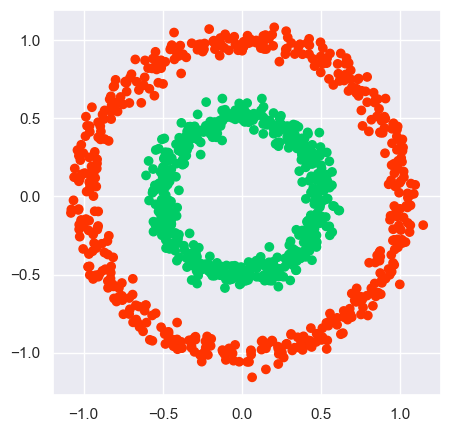

In [4]:
# Генерация данных
n_samples = 1024
X, y = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)

# Визуализация данных
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright)
plt.show()

Обучите реализованную ранее нейросеть решать задачу классификации на основе этой выборки.

*Периодически во время обучения рисуйте график лосса. Если он возрастает, стоит поискать ошибку.*

In [5]:
# Создаем модель
model_one = TwoLayersNNClassifier(
    input_size=2,  # 2 признака на входе
    hidden_size=10,  # 10 нейронов в скрытом слое
    n_epoch=50000,  # Количество эпох
    weight_init_scale=0.1,  # Масштаб инициализации весов
    learning_rate = 1
)

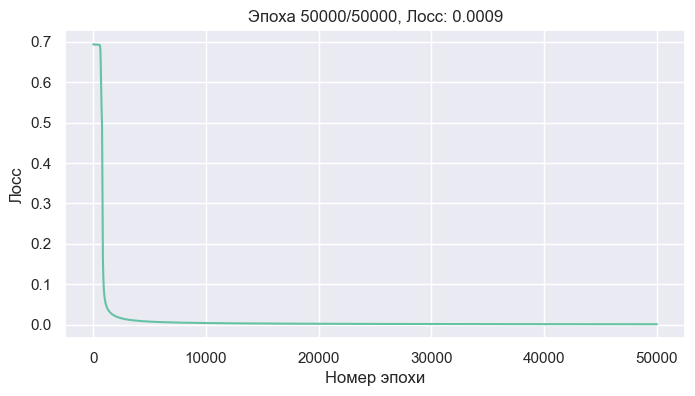

In [6]:
# Обучаем с визуализацией каждые 20 эпох
model_one.fit(X, y, plot_freq=100)

С помощью функции `np.meshgrid` создайте двухмерную сетку в диапазоне $[-1.5, 1.5]$ по каждой координате с шагом не более $0.02$. Для каждой точки сетки посчитайте оценки вероятностей принадлежности тому или иному классу. 

In [8]:
# Создаем сетку
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Вычисляем вероятности для каждой точки сетки
grid_points = np.c_[xx.ravel(), yy.ravel()]  # Объединяем в матрицу (N, 2)
Z = model_one.predict_proba(grid_points)[:, 1]  # Берем вероятности класса 1
Z = Z.reshape(xx.shape)  # Возвращаем исходную форму сетки

Визуализируйте полученные предсказания классов и вероятностей.

*Если у вас получилось плохое качество, попробуйте увеличить количество нейронов. Если не помогает, возможно, где-то ошибка.*

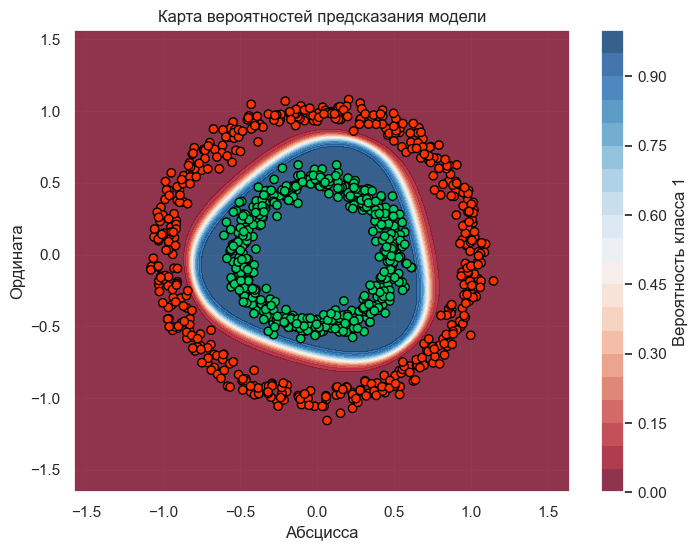

In [9]:
# Визуализация
plt.figure(figsize=(8, 6))
contour = plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.8)
plt.colorbar(contour, label='Вероятность класса 1')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright, edgecolors='k')
plt.title("Карта вероятностей предсказания модели")
plt.xlabel("Абсцисса")
plt.ylabel("Ордината")
plt.show()

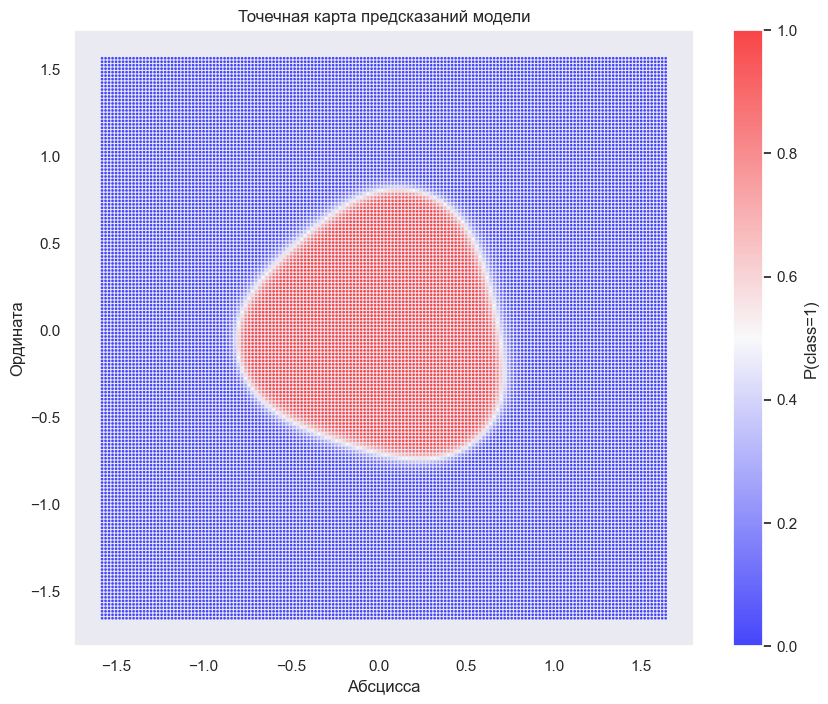

In [10]:
plt.figure(figsize=(10, 8))

# Создаем сетку
h = 0.02  # Шаг сетки
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Предсказание вероятностей
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model_one.predict_proba(grid_points)[:, 1]

# Точечная визуализация
plt.scatter(xx.ravel(), yy.ravel(), c=Z, cmap='bwr', 
            s=15, marker='.', alpha=0.7, edgecolors='none')

# Настройки графика
plt.colorbar(label='P(class=1)')
plt.title("Точечная карта предсказаний модели")
plt.xlabel("Абсцисса")
plt.ylabel("Ордината")
plt.grid(False)
plt.show()

Немного увеличим разброс данных

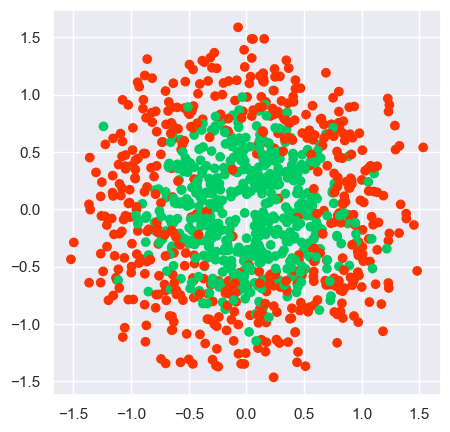

In [11]:
# Генерация данных
n_samples = 1024
X, y = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.25)

# Визуализация данных
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright)
plt.show()

Повторите те же действия с новыми данными.

In [19]:
# Создаем модель
model_two = TwoLayersNNClassifier(
    input_size=2,
    hidden_size=10,  # 10 нейронов в скрытом слое
    n_epoch=80000,  # Количество эпох
    weight_init_scale=0.1,  # Масштаб инициализации весов
    learning_rate = 2.0
)

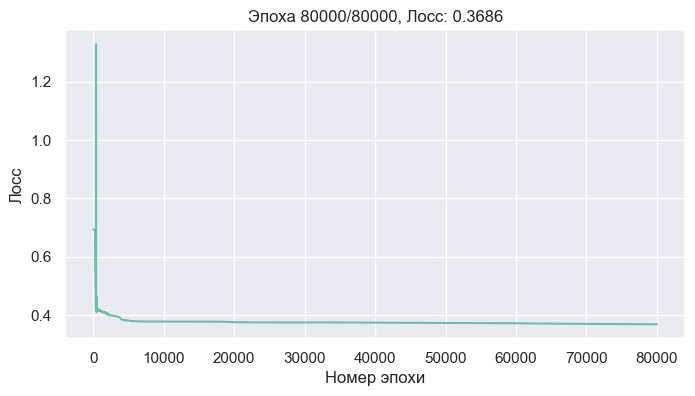

In [20]:
# Обучаем с визуализацией каждые 1000 эпох
model_two.fit(X, y, plot_freq=1000)

In [21]:
# Сетка с шагом 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Вероятности для каждой точки сетки
grid_points = np.c_[xx.ravel(), yy.ravel()]  # Объединяем в матрицу (N, 2)
Z = model_two.predict_proba(grid_points)[:, 1]  # Берем вероятности класса 1
Z = Z.reshape(xx.shape)  # Возвращаем исходную форму сетки

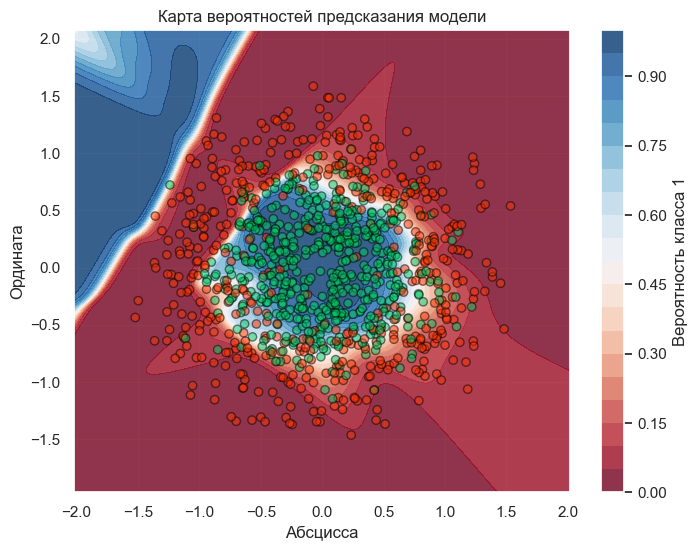

In [22]:
# 3. Визуализация
plt.figure(figsize=(8, 6))
contour = plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.8)
plt.colorbar(contour, label='Вероятность класса 1')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright, edgecolors='k', alpha = 0.5)
plt.title("Карта вероятностей предсказания модели")
plt.xlabel("Абсцисса")
plt.ylabel("Ордината")
plt.show()

**Выводы:**

Построенная нейросеть с 10 скрытыми нейронами была обучена на двух выборках с малой и чуть большей погрешностями. Как видно на иллюстрации, распределение похоже на круги с серединой в середине между красными и зелёными входными данными, что вполне ожидаемо. На втором графике есть область слева вверху, она говорит о чувствительности модели к выбросам. Добавление нейронов в слой слабо улучшает рещультат

**4.** Теперь давайте применим нашу нейронную сеть к данным MNIST.

Загрузите данные. Для этого воспользуйтесь кодом из задачи 1. Обратите внимание, что поскольку наша сеть реализована на `numpy` и принимает `numpy`-матрицы, потребуется предварительно перевести `torch`-тензоры в `numpy`-массивы.

Поскольку наша сеть была разработана для бинарной классификации, мы будем рассматривать изображения, на которых представлены только две цифры: `0` и `1`. Возьмите по 1000 изображений каждого символа и преобразуйте их в векторы. Также выделите изображения из тестовой выборки, соответствующие этим цифрам.

In [44]:
def load_mnist(
    train_size: int = 1000, test_size: int = 100, target_size: int = 14
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Загружает и подготавливает данные MNIST для обучения и тестирования.

    Параметры:
    train_size (int): Количество обучаемых данных для каждой цифры (0 и 1). По умолчанию 1000.
    test_size (int): Количество тестовых данных для каждой цифры (0 и 1). По умолчанию 100.
    target_size (int): Размер, до которого уменьшаются изображения. По умолчанию 14.

    Возвращает:
    train_images (np.ndarray): Массив с изображениями для обучения.
    train_labels (np.ndarray): Массив с метками для обучения.
    test_images (np.ndarray): Массив с изображениями для тестирования.
    test_labels (np.ndarray): Массив с метками для тестирования.

    Данные загружаются из набора MNIST, нормализуются, уменьшаются в
    размере и преобразуются в векторы. Для обучения используется только
    часть (train_size) от исходного набора данных для каждой цифры.
    """

    PIXEL_MAX_VALUE = 255.0  # Для нормализации значений пикселей

    # Создаем преобразование для данных: конвертируем изображения в тензоры PyTorch
    transform = transforms.Compose(
        [
            # Преобразует изображение в тензор и нормализует значения в диапазоне [0, 1]
            transforms.ToTensor(),
        ]
    )

    # Загружаем обучающий и тестовый наборы данных MNIST
    train_dataset = MNIST(root=r"C:\Users\Name\AD_Name", train=True, transform=transform, download=True)
    test_dataset = MNIST(root=r"C:\Users\Name\AD_Name", train=False, transform=transform, download=True)

    # Фильтруем данные для цифр 0 и 1
    train_indices_0 = np.where(train_dataset.targets.numpy() == 0)[0]
    train_indices_1 = np.where(train_dataset.targets.numpy() == 1)[0]

    test_indices_0 = np.where(test_dataset.targets.numpy() == 0)[0]
    test_indices_1 = np.where(test_dataset.targets.numpy() == 1)[0]

    # Выбираем часть обучающего набора данных для каждой цифры
    train_indices_0 = np.random.choice(train_indices_0, train_size // 2, replace=False)
    train_indices_1 = np.random.choice(train_indices_1, train_size // 2, replace=False)

    test_indices_0 = np.random.choice(test_indices_0, test_size // 2, replace=False)
    test_indices_1 = np.random.choice(test_indices_1, test_size // 2, replace=False)

    train_indices = np.concatenate((train_indices_0, train_indices_1))
    test_indices = np.concatenate((test_indices_0, test_indices_1))

    # Преобразуем изображения в тензоры и нормализуем их, деля на PIXEL_MAX_VALUE
    train_images = train_dataset.data[train_indices].unsqueeze(1).float() / PIXEL_MAX_VALUE
    test_images = test_dataset.data[test_indices].unsqueeze(1).float() / PIXEL_MAX_VALUE

    # Уменьшаем размер изображений до target_size x target_size с использованием билинейной интерполяции
    train_images = torch.nn.functional.interpolate(
        train_images, size=(target_size, target_size), mode="bilinear", align_corners=False
    )
    test_images = torch.nn.functional.interpolate(
        test_images, size=(target_size, target_size), mode="bilinear", align_corners=False
    )

    # Преобразуем изображения в векторы (разворачиваем в одномерные массивы)
    train_images = train_images.view(len(train_indices), -1)
    test_images = test_images.view(len(test_indices), -1)

    # Получаем метки для выбранных обучающих и тестовых данных
    train_labels = train_dataset.targets[train_indices]
    test_labels = test_dataset.targets[test_indices]

    # Преобразуем тензоры PyTorch в массивы NumPy
    train_images = train_images.numpy()
    train_labels = train_labels.numpy()
    test_images = test_images.numpy()
    test_labels = test_labels.numpy()

    return train_images, train_labels, test_images, test_labels

In [45]:
train_images, train_labels, test_images, test_labels = load_mnist()

print("Train:", train_images.shape, train_labels.shape)
print("Test:", test_images.shape, test_labels.shape)

Train: (1000, 196) (1000,)
Test: (100, 196) (100,)


Обучите реализованную ранее нейронную сеть к этим данным.


In [47]:
# Создаем и обучаем модель
model_four = TwoLayersNNClassifier(
    input_size=196,
    hidden_size=10,  # 10 нейронов в скрытом слое
    n_epoch=4000,  # Количество эпох
    weight_init_scale=0.1,  # Масштаб инициализации весов
    learning_rate = 1.0
)

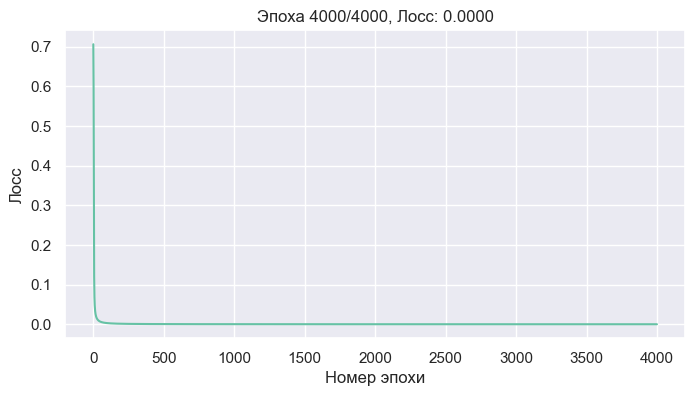

In [48]:
# Обучаем с визуализацией каждые 1000 эпох
model_four.fit(train_images, train_labels, plot_freq=1000)

Посчитайте качество обученной нейросети на тестовой выборке. Можете ли вы сказать, насколько хорошо сеть обучилась?

In [51]:
# посчитаем через accuracy
test_preds = model_four.predict(test_images)
test_accuracy = np.mean(test_labels.flatten() == test_preds.flatten())
print(f"accuracy: {test_accuracy:.2f}")

accuracy: 1.00


**Выводы:**

Была обучена нейросеть с десятью нейронами на выборке из нулей и единиц из MNIST. На тестовой выдорке она показала безупречную точность. Значит, десяти нейронов достаточно. Анализируя график лосс, можно сделать выывод, что нейросети хватит 250 эпох, чтобы обучиться.

---
### Задача 4.

Рассмотрим глубокую нейронную сеть, которая
* принимает на вход $x\in\mathbb{R}^d$,
* возвращает $y\in\{0, 1\}$,
* содержит $99$ полносвязных слоев (`Linear`) с функцией активации $\tanh$, за исключением последнего слоя,
* последний слой использует функцию активации логистическая сигмоида.

В качестве лосса $\mathscr{L}(\theta)$ возьмем кросс-энтропию.

**1.** Распишите градиент лосса по весам первого слоя $W_1$. Какова сложность этой операции?

## Прямое распространение

### Первый слой ($l = 1$)
  $$z_1^j = \sum_{i=1}^d W_1^{ji} x_i + b_1^j$$  
  $$a_1^j = \tanh(z_1^j)$$

### Скрытые слои ($l = 2..99$)
Для каждого слоя $l$ от 2 до 99:
  $$z_l^j = \sum_{i=1}^{n_{l-1}} W_l^{ji} a_{l-1}^i + b_l^j$$  
  где $n_{l-1}$ — количество нейронов в слое $l-1$  
  $$a_l^j = \tanh(z_l^j)$$

### Последний слой ($l = 100$) 
  $$z_{100} = \sum_{i=1}^{n_{99}} W_{100}^{1i} a_{99}^i + b_{100}$$  
  выход — скаляр, т.к. бинарная классификация  
  $$\hat{y} = \sigma(z_{100}) = \frac{1}{1 + e^{-z_{100}}}$$    

## Обратное распространение (Backward Pass)

### Последний слой ($l = 100$)
  $$\delta_{100} = \hat{y} - y$$  
  (разница между предсказанием и истинным значением)  
  $$\frac{\partial \mathscr{L}}{\partial W_{100}^{1i}} = \delta_{100} \cdot a_{99}^i$$  
  $$\frac{\partial \mathscr{L}}{\partial b_{100}} = \delta_{100}$$

### Скрытые слои ($l = 99..2$)
Для каждого слоя $l$ от 99 до 2:
- **Ошибка на слое $l$:**  
  $$\delta_l^j = (1 - (a_l^j)^2) \cdot \sum_{k=1}^{n_{l+1}} W_{l+1}^{kj} \delta_{l+1}^k$$  
  (производная $\tanh$ + взвешенная сумма ошибок следующего слоя)  
  $$\frac{\partial \mathscr{L}}{\partial W_l^{ji}} = \delta_l^j \cdot a_{l-1}^i$$  
  $$\frac{\partial \mathscr{L}}{\partial b_l^{j}} = \delta_l^j$$

### Первый слой ($l = 1$)
  $$\delta_1^j = (1 - (a_1^j)^2) \cdot \sum_{k=1}^{n_2} W_2^{kj} \delta_2^k$$  
  $$\frac{\partial \mathscr{L}}{\partial W_1^{ji}} = \delta_1^j \cdot x_i$$  
  $$\frac{\partial \mathscr{L}}{\partial b_1^{j}} = \delta_1^j$$

## Сложность вычислений

### Прямое распространение
- Для каждого слоя $l$ от 1 до 99:  
  $$O(n_{l-1} \cdot n_l)$$  
  где $n_0 = d$ — размер входа,  
- Для последнего слоя:  
  $$O(n_{99} \cdot 1)$$  

### Обратное распространение
- Для каждого слоя $l$ от 99 до 1:  
  $$O(n_l \cdot n_{l-1})$$  

### Общая сложность
Если все скрытые слои имеют одинаковый размер $n$, то:  
$$O(99 \cdot n^2)$$  
 
В итоге сложность вычисления градиента для $W_1$ = **$O(n^2 * d)$** 

Нарисуйте график функции активации и ее производной.

In [31]:
# Определяем функцию активации tanh и её производную
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

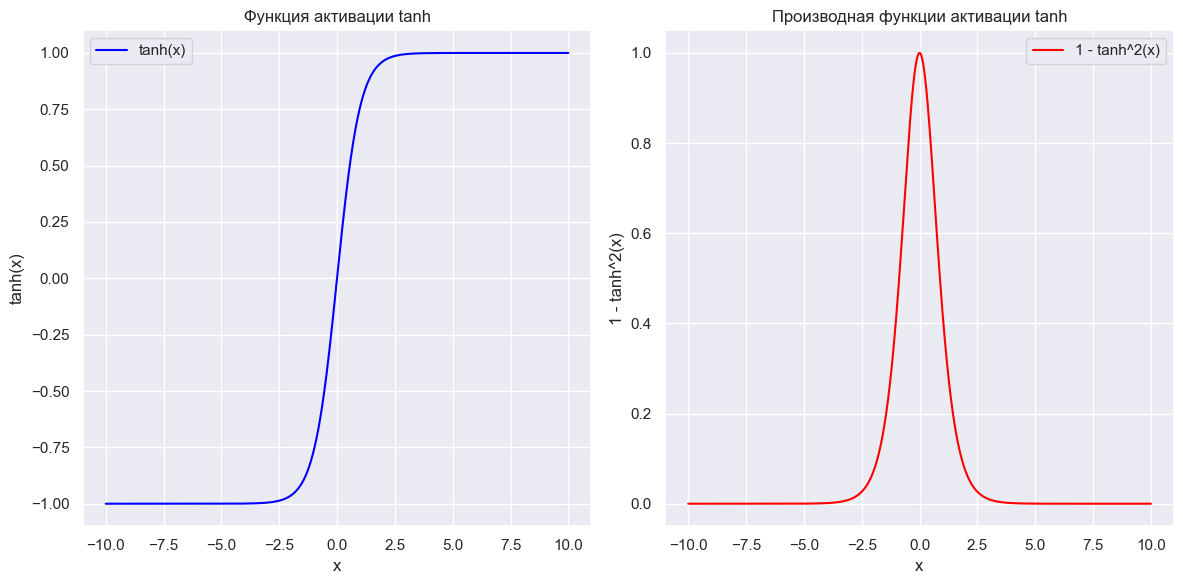

In [33]:
# Создаем массив значений x
x = np.linspace(-10, 10, 1000)

# Вычисляем значения функций
y_tanh = tanh(x)
y_tanh_derivative = tanh_derivative(x)

# Строим графики
plt.figure(figsize=(12, 6))

# График функции активации tanh
plt.subplot(1, 2, 1)
plt.plot(x, y_tanh, label='tanh(x)', color='blue')
plt.title('Функция активации tanh')
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.grid(True)
plt.legend()

# График производной функции активации tanh
plt.subplot(1, 2, 2)
plt.plot(x, y_tanh_derivative, label="1 - tanh^2(x)", color='red')
plt.title('Производная функции активации tanh')
plt.xlabel('x')
plt.ylabel("1 - tanh^2(x)")
plt.grid(True)
plt.legend()

# Отображаем графики
plt.tight_layout()
plt.show()

На основе графика проанализируйте, что будет происходить с градиентом по весам первого слоя, если нейросеть "ненулевая", иначе говоря, на промежуточных слоях может выдавать различные значения, в том числе довольно большие.

Если значения довольно большие, то производная будет около нулевая, и поскольку градиент на неё умножается, то она его занулит. Тогда модель будет обучаться очень долго. Если значения около нуля, то производная около единицы, значит градиент не теряется, и модель обучается быстро.

**2.** Реализуйте эту нейросеть на **PyTorch**.

*Примечание.* Каждый слой должен быть инициализирован отдельно. Нельзя создавать копии уже инициализированного слоя.

In [100]:
class DeepNeuralNetwork:

    def __init__(self, input_dim, hidden_dim=10, output_dim=1, lr=0.001, weight_init_scale: float = 0.01):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lr = lr
        self.weight_init_scale = weight_init_scale
        self.loss_history = []

        # Инициализация весов и смещений
        self.weights = []
        self.biases = []

        # Все слои заполняем случайными числами, матрицы нормируем
        # Первый слой
        self.weights.append(torch.randn(hidden_dim, input_dim) * weight_init_scale)
        self.biases.append(torch.randn(hidden_dim))

        # Скрытые слои (98 слоев)
        for _ in range(98):
            self.weights.append(torch.randn(hidden_dim, hidden_dim) * weight_init_scale)
            self.biases.append(torch.randn(hidden_dim))

        # Последний слой
        self.weights.append(torch.randn(output_dim, hidden_dim) * weight_init_scale)
        self.biases.append(torch.randn(output_dim))

    def tanh(self, x):
        return torch.tanh(x)

    def tanh_derivative(self, x):
        return 1 - torch.tanh(x) ** 2

    def sigmoid(self, x):
        return 1 / (1 + torch.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def output_gradient(self, logits, y):
        """Вычисляет градиент по выходу сети до применения сигмоиды.
    
        Параметры:
            logits : Предсказанные значения.
            y : Истинные значения.
    
        Возвращает:
             Градиент по выходу до применения сигмоиды.
        """
        return self.sigmoid(logits) - y

    def binary_crossentropy(self, y_pred, y_true):
        """Вычисляет значение бинарной кросс-энтропии.

        Параметры:
            y_pred : Предсказанные значения (вероятности).
            y_true : Истинные значения (0 или 1).

        Возвращает:
            float: Значение бинарной кросс-энтропии.
        """
        epsilon = 1e-15
        y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
        logits = torch.log(y_pred / (1 - y_pred))
        loss = torch.mean(torch.logsumexp(torch.stack([torch.zeros_like(logits), -logits]), dim=0) + (1 - y_true) * logits)
        return loss

    def forward(self, x):
        self.activations = [x]
        self.s_values = []

        # Прямой проход
        for i in range(len(self.weights) - 1):
            s = torch.matmul(self.activations[-1], self.weights[i].t()) + self.biases[i]
            self.s_values.append(s)
            u = self.tanh(s)
            self.activations.append(u)

        # Последний слой
        s = torch.matmul(self.activations[-1], self.weights[-1].t()) + self.biases[-1]
        self.s_values.append(s)
        u = self.sigmoid(s)
        self.activations.append(u)

        return u

    def backward(self, x, y):
        # Инициализация градиентов (если это первый вызов backward)
        self.d_weights = [torch.zeros_like(w) for w in self.weights]
        self.d_biases = [torch.zeros_like(b) for b in self.biases]

        # Обратное распространение
        delta = self.output_gradient(self.s_values[-1], y)
        self.d_weights[-1] += torch.matmul(delta.t(), self.activations[-2])
        self.d_biases[-1] += delta.sum(dim=0)

        for i in reversed(range(len(self.weights) - 1)):
            delta = torch.matmul(delta, self.weights[i + 1]) * self.tanh_derivative(self.activations[i + 1])
            self.d_weights[i] += torch.matmul(delta.t(), self.activations[i])
            self.d_biases[i] += delta.sum(dim=0)

    def update_weights(self):
        for i in range(len(self.weights)):
            self.weights[i] -= self.lr * self.d_weights[i] / self.d_weights[i].size(0)
            self.biases[i] -= self.lr * self.d_biases[i] / self.d_biases[i].size(0)

    def plot_gradients(self):
        mean_grads = []
        max_grads = []
    
        for d_weight in self.d_weights:
            mean_grads.append(d_weight.abs().mean().item())
            max_grads.append(d_weight.abs().max().item())
    
        layers = list(range(1, len(mean_grads) + 1))
    
        plt.figure(figsize=(12, 6))
        plt.plot(layers, mean_grads, label='Mean Gradient')
        plt.plot(layers, max_grads, label='Max Gradient')
        plt.xlabel('Layer Number')
        plt.ylabel('Gradient Value')
        plt.title('Gradient Values by Layer')
        plt.legend()
        plt.grid(True)
        plt.show()

    def fit(self, train_loader, num_epochs=5):
        for epoch in range(num_epochs):
            running_loss = 0.0
            for images, labels in train_loader:
                # Преобразуем изображения в вектор
                images = images.view(images.size(0), -1)
    
                # Преобразуем метки в бинарный формат
                labels = labels.float().unsqueeze(1)
    
                # Прямое распространение
                outputs = self.forward(images)
    
                # Вычисление потерь
                loss = self.binary_crossentropy(outputs, labels)
    
                # Обратное распространение
                self.backward(images, labels)
    
                running_loss += loss.item()
    
            # Обновление весов после обработки всех батчей
            self.update_weights()
    
            # Сохранение лосса для текущей эпохи
            self.loss_history.append(running_loss / len(train_loader))

            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')

    def predict(self, x):
        """Возвращает предсказания для входных данных.
    
        Параметры:
            x : Входные данные.
    
        Возвращает:
            Предсказания.
        """
        with torch.no_grad():
            return self.forward(x)

    def estimate(self, test_loader):
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                # Преобразуем изображения в вектор
                images = images.view(images.size(0), -1)
    
                # Преобразуем метки в бинарный формат
                labels = labels.float().unsqueeze(1)
    
                # Получаем предсказания
                outputs = self.predict(images)
    
                # Преобразуем выходные данные в бинарные предсказания
                predicted = (outputs > 0.5).float()
    
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
    
        accuracy = correct / total
        print(f'Accuracy of the network on the test images: {accuracy:.2f}%')
        return accuracy

Аналогично задаче 3 попробуйте обучить эту нейросеть для классификации изображений с цифрами 0 и 1 из датасета MNIST. Скорее всего весь датасет не поместится в память, поэтому предлагается использовать случайную подвыборку (батч) размера 32 на каждом шаге обучения.

In [101]:
def load_MNIST_torch() :
    # Определяем трансформации для данных
    transform = transforms.Compose([
        transforms.Resize((14, 14)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    # Загружаем датасет MNIST
    train_dataset = datasets.MNIST(root=r"C:\Users\Name\AD_Name", train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root=r"C:\Users\Name\AD_Name", train=False, download=True, transform=transform)
    
    # Фильтруем
    train_indices = [i for i, (_, label) in enumerate(train_dataset) if label in [0, 1]]
    test_indices = [i for i, (_, label) in enumerate(test_dataset) if label in [0, 1]]
    train_dataset = Subset(train_dataset, train_indices)
    test_dataset = Subset(test_dataset, test_indices)
    
    # DataLoader для обучения и тестирования
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    return train_loader, test_loader

In [102]:
train_loader, test_loader = load_MNIST_torch()

In [103]:
model = DeepNeuralNetwork(input_dim = 196, hidden_dim = 10, output_dim = 1, lr = 0.01)
model.fit(train_loader, num_epochs=15)

Epoch [1/15], Loss: 0.6911
Epoch [2/15], Loss: 0.6913
Epoch [3/15], Loss: 0.6914
Epoch [4/15], Loss: 0.6911
Epoch [5/15], Loss: 0.6925
Epoch [6/15], Loss: 0.6915
Epoch [7/15], Loss: 0.6937
Epoch [8/15], Loss: 0.6911
Epoch [9/15], Loss: 0.6914
Epoch [10/15], Loss: 0.6916
Epoch [11/15], Loss: 0.6918
Epoch [12/15], Loss: 0.6916
Epoch [13/15], Loss: 0.6914
Epoch [14/15], Loss: 0.6950
Epoch [15/15], Loss: 0.6944


In [104]:
model.estimate(test_loader)

Accuracy of the network on the test images: 0.54%


0.5366430260047281

Постройте график зависимости среднего и максимального абсолютного значения градиента по весам для каждого слоя от номера слоя.

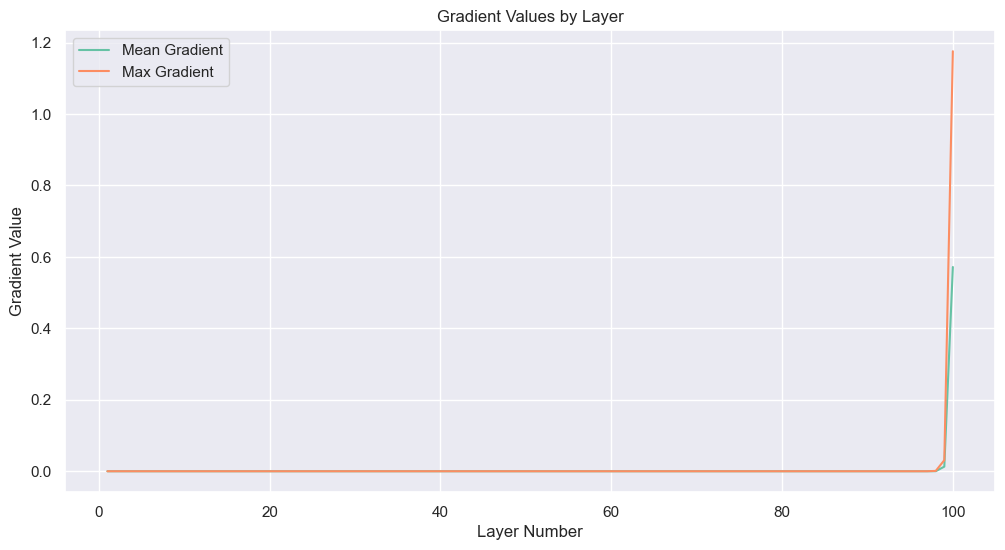

In [105]:
model.plot_gradients()

**Выводы:**

Была обучена модель глубокого обучения с функциями активации чангенс и сигмоида последняя. Как видно, градиент зануляется на чангенсах. Поэтому модель почти не обучается.

*Примечание.* Подобная ситуация известна как "паралич" нейросети. Именно поэтому такие функции активации, как ReLU, стали очень популярными. Для преодоления этого паралича существует множество методов, многие из которых мы рассмотрим на 3 курсе.